In [3]:
import pandas as pd
import numpy as np
import itertools

from thefuzz import fuzz, process

In [4]:
df1 = pd.read_csv('data/companies_1.csv')
df2 = pd.read_csv('data/companies_2.csv')

In [5]:
df1.sort_values(by='CLIENT', inplace=True)

In [6]:
df1

,CLIENT
1678,AECOM America
813,AECOM America Co.
1799,AECOM America Corp.
576,AECOM America SA
756,AECOM Global Co.
...,...
1985,Zoom Video Communications Systems Inc.
1647,Zoom Video Communications Systems Ltd.
577,Zoom Video Communications Technologies Group
1017,Zoom Video Communications Technologies LLC


In [7]:
df2.sort_values(by='Firm Name', inplace=True)

In [8]:
df2

,Firm Name
1237,ABBVIE AMERICA GROUP
1163,ABBVIE AMERICA PLC
606,ABBVIE SERVICES GROUP
1691,ADIDAS AMERICA AMERICA PLC
1397,ADIDAS AMERICA HOLDINGS
...,...
1406,walmart america sa
1622,walmart technologies corp.
1858,zoom video communications global plc
101,zoom video communications ltd.


## Introduction

In this project, we're going to resolve a very tough problem, which is identifying similar strings that are not completely equal. It's a very common and challenging data-cleaning task, so let's get right into it!

We have two CSVs containing company names. The problem is that the company names in these two CSVs don't match. Both have a single column, but if you explore them, you'll immediately spot the anomalies. For example, here are the first 5 rows of the first CSV (companies_1.csv):

>
> CLIENT
>
> "Adobe Systems, Inc."
>
> Adventist Health
>
> AECOM                                   <------ CHECK THIS OUT
>
> Aerojet Rockedyne Holdings (GenCorp)
>
> Alameda-Contra Costa Transit District
>
> Alaska Community Foundation
>
> Alaska Retirement Management Board
>
> "Alexander & Baldwin, Inc."
>
> "Allergan, Inc."
>
> And here's for the second CSV (companies_2.csv):
>

> 
>Firm Name
> 
>"AAA Northern California, Nevada & Utah Auto Exchange"
> 
>ACCO Engineered Systems
> 
>Adams County Retirement Plan
> 
>"Adidas America, Inc."
> 
>"Adobe Systems, Inc."
> 
>"Advanced Micro Devices, Inc."
> 
>AECOM Technology Corporation             <------ CHECK THIS OUT
> 
>Aera Energy LLC
> 
>"Aerojet Rocketdyne Holdings, Inc."
> 
>You can see that the company AECOM appears as AECOM in CSV1, but as AECOM Technology 
> 
>Corporation in CSV2.

To do so, we're going to use an external library called [thefuzz](https://github.com/seatgeek/thefuzz) that contains functionality to compute the [Levenshtein distance](https://en.wikipedia.org/wiki/Levenshtein_distance) between two strings. More on this later.

Your job will be cleaning this data and matching the columns in both CSVs. Let's get started.

### Data Preprocessing
Before we can compare the company names, we need to read the data and align the companies for comparison. To do so, we'll need to use the itertools.product function to create the "cartesian product" between the two CSVs. Very briefly, the Cartesian Product of two collections A and B, returns a combination of ALL the elements in both A and B.

![Cartesian_Product](Cartesian_Product.png "Cartesian_Product")

Example:

> A = ["Apple", "Alphabet", "Microsoft"]
> B = ["MSFT", "Alphabet/Google", "Apple inc."]

` list(itertools.product(A, B))`

```
[('Apple', 'MSFT'),
 ('Apple', 'Alphabet/Google'),
 ('Apple', 'Apple inc.'),
 ('Alphabet', 'MSFT'),
 ('Alphabet', 'Alphabet/Google'),
 ('Alphabet', 'Apple inc.'),
 ('Microsoft', 'MSFT'),
 ('Microsoft', 'Alphabet/Google'),
 ('Microsoft', 'Apple inc.')]
```
As you can see, every element in A is matched with every element in B.

## Data Preprocessing

#### 1. Create the df dataframe containing the product of the two CSVs

We have already read the 2 CSVs into the df1 and df2 variables. Now, use the itertools.product method to create a resulting dataframe df that will contain the product of the two CSVs. The columns should be named CSV 1 and CSV 2.

In [9]:
df = pd.DataFrame(
  itertools.product(df1['CLIENT'].values, df2['Firm Name']),
  columns=['CSV 1', 'CSV 2'])

In [10]:
df.head()

,CSV 1,CSV 2
0,AECOM America,ABBVIE AMERICA GROUP
1,AECOM America,ABBVIE AMERICA PLC
2,AECOM America,ABBVIE SERVICES GROUP
3,AECOM America,ADIDAS AMERICA AMERICA PLC
4,AECOM America,ADIDAS AMERICA HOLDINGS


In [11]:
df.shape

(4000000, 2)

# 🧠 Understanding `thefuzz` Library (Simple Explanation)

The **`thefuzz`** library (previously known as **`fuzzywuzzy`**) helps you **compare two strings** and tells you **how similar they are** — even if they are not exactly the same.

It returns a **similarity score between 0 and 100**:
- **100 → perfect match** (exactly same)
- **0 → totally different**

## 🔍 Example

```python
from thefuzz import fuzz

fuzz.ratio("Apple Inc.", "Apple Inc.")           # → 100
fuzz.ratio("Apple Inc.", "Apple Incorporated")   # → 95
fuzz.ratio("Apple Inc.", "Microsoft")            # → 10
```

👉 It looks at both words and letters, and calculates how much they overlap or differ.

### ⚙️ How Does It Work (Simple Idea)

It uses something called Levenshtein Distance — a method to count how many changes (insert, delete, replace) it takes to turn one string into another.

Example:

To turn "cat" into "car"
- → Only 1 letter changes (t → r)
- → So the distance is small → high similarity.

##3 🧩 Main Functions in thefuzz

Here are the most useful functions and what they do 👇

### 1️⃣ fuzz.ratio(s1, s2)

Basic comparison — compares two strings directly and gives a score (0–100).

```python
fuzz.ratio("Apple Inc.", "Apple Incorporated")  # 95
fuzz.ratio("AECOM", "AECOM Technology Corporation")  # 83
```
💡 Use it when both strings are similar in structure and length.

### 2️⃣ fuzz.partial_ratio(s1, s2)

Partial match — checks if one string is contained within another.

```python
fuzz.partial_ratio("AECOM", "AECOM Technology Corporation")  # 100
```

💡 Use this when one string is a shorter version of the other.

### 3️⃣ fuzz.token_sort_ratio(s1, s2)

Ignores word order — sorts the words before comparing.
```python
fuzz.token_sort_ratio("Corporation AECOM", "AECOM Corporation")  # 100
```

💡 Use this when words are the same but in a different order.

### 4️⃣ fuzz.token_set_ratio(s1, s2)

Ignores duplicates and extra words — focuses on shared words.
```python
fuzz.token_set_ratio("AECOM Corporation Limited", "AECOM Corporation")  # 100
```

💡 Use this when there are extra or missing words in one of the names.

### 5️⃣ process.extract() and process.extractOne()

Finds the closest match(es) from a list of strings.
```python
from thefuzz import process

choices = ["Google LLC", "AECOM Technology Corporation", "Apple Inc."]

process.extractOne("AECOM", choices)

# → ('AECOM Technology Corporation', 100)
```

💡 `extractOne` returns the best match and its score.
`extract` can return multiple top matches.

### 📊 When to Use What
| Situation                      | Function                | Example                                       |
| :------------------------------: | :-----------------------: | :---------------------------------------------: |
| Exact or nearly exact match    | `fuzz.ratio`            | `"Apple Inc."`, `"Apple Inc"`                 |
| One string is shorter          | `fuzz.partial_ratio`    | `"AECOM"`, `"AECOM Technology Corp"`          |
| Words out of order             | `fuzz.token_sort_ratio` | `"Corp AECOM"`, `"AECOM Corp"`                |
| Extra/missing words            | `fuzz.token_set_ratio`  | `"AECOM Corporation Limited"`, `"AECOM Corp"` |
| Find closest match from a list | `process.extractOne`    | `"AECOM"`, list of company names              |


### Calculating the Lavenshtein Distance
We're going to use the `partial_ratio` function from the fuzz module to compute the "distance" between two strings. The result is a number between `0` and `100`, with `100` indicating a "perfect" match. Please keep in mind that this method is not perfect, as shown in the examples about `Microsoft` in the notebook.

In [12]:
fuzz.partial_ratio('Apple', 'Apple Inc.')

100

In [13]:
fuzz.partial_ratio
('Apple', 'Microsoft')

('Apple', 'Microsoft')

In [14]:
fuzz.partial_ratio('Microsoft', 'MSFT')

40

#### 2. Create a new column Ratio Score that contains the distance for all the rows in df

Now apply the function fuzz.partial_ratio to all the companies in df to calculate the distance between them. Store the distance in a new column named Ratio Score. It'll look similar to:

In [15]:
score = [fuzz.partial_ratio(c1, c2) for c1, c2 in df.values]

In [16]:
score[:10]

[38, 38, 30, 38, 31, 31, 43, 32, 32, 32]

In [17]:
df['Ratio Score'] = score

In [18]:
df.head(20)

,CSV 1,CSV 2,Ratio Score
0,AECOM America,ABBVIE AMERICA GROUP,38
1,AECOM America,ABBVIE AMERICA PLC,38
2,AECOM America,ABBVIE SERVICES GROUP,30
3,AECOM America,ADIDAS AMERICA AMERICA PLC,38
4,AECOM America,ADIDAS AMERICA HOLDINGS,31
5,AECOM America,ADIDAS AMERICA TECHNOLOGIES LLC,31
6,AECOM America,ADOBE SYSTEMS AMERICA SA,43
7,AECOM America,ADOBE SYSTEMS CORP.,32
8,AECOM America,ADOBE SYSTEMS GLOBAL HOLDINGS,32
9,AECOM America,ADOBE SYSTEMS GROUP,32


#### 3. How many rows have a Ratio score of 90 or more?

In [19]:
df.loc[df['Ratio Score'] >= 90].head()

,CSV 1,CSV 2,Ratio Score
14,AECOM America,AECOM,100
15,AECOM America,AECOM,100
16,AECOM America,AECOM America LLC LLC,100
2014,AECOM America Co.,AECOM,100
2015,AECOM America Co.,AECOM,100


In [20]:
df.loc[df['Ratio Score'] >= 90].shape

(10538, 3)

#### 4. What's the corresponding company in CSV1 to AECOM in CSV2?

We saw that in `CSV 2` there's a company `AECOM`, what's the corresponding value in `CSV 1`? The higher the `Ratio Score`, the more likely it is to be a match. So, use the `Ratio Score` greater than `90` to filter the results.

In [21]:
csv1_aecom = df.loc[(df['CSV 2'] == 'AECOM') & (df['Ratio Score'] >= 90)]

In [22]:
csv1_aecom.shape

(44, 3)

#### 5. What's the corresponding CSV 2 company of Starbucks Ltd.?

`CSV 1` company is `Starbucks Ltd.`, what's the corresponding name in `CSV 2`?

In [29]:
csv1_star = df.loc[(df['CSV 1'] == 'Starbucks Ltd.') & (df['Ratio Score'] >= 80)]

In [34]:
csv1_star.sort_values(by='Ratio Score', ascending=False).iloc[0]

CSV 1          Starbucks Ltd.
CSV 2           Starbucks Co.
Ratio Score                87
Name: 3339513, dtype: object

#### 6. Is there a matching company for `Pinnacle West Capital Corporation Services Co.` in column CSV 2?

Column `CSV 1` contains `Pinnacle West Capital Corporation Services Co.`, name a matching company in column `CSV 2` with a ratio score more than `90`?

In [35]:
csv1_pinnacle = df.loc[(df['CSV 1'] == 'Pinnacle West Capital Corporation Services Co.')
              & (df['Ratio Score'] >= 90)]

In [36]:
csv1_pinnacle

,CSV 1,CSV 2,Ratio Score
2809263,Pinnacle West Capital Corporation Services Co.,Pinnacle West Capital Corporation America Co.,91
2809272,Pinnacle West Capital Corporation Services Co.,Pinnacle West Capital Corporation LLC,96
2809274,Pinnacle West Capital Corporation Services Co.,Pinnacle West Capital Corporation Ltd.,94
2809276,Pinnacle West Capital Corporation Services Co.,Pinnacle West Capital Corporation Services Hol...,97


#### 7. How many matching companies are there for `County of Los Angeles Deferred Compensation Program Global Group`?

`CSV 1` contains the `County of Los Angeles Deferred Compensation Program Global Group`. How many matching companies seem to be in `CSV 2`?

In [37]:
csv_la = df.loc[(df['CSV 1'] == 'County of Los Angeles Deferred Compensation Program Global Group')
                & (df['Ratio Score'] > 90)]

In [40]:
pd.options.display.max_colwidth = None

In [41]:
csv_la.sort_values(by='Ratio Score', ascending=False)

,CSV 1,CSV 2,Ratio Score
1444627,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Global Group,100
1444629,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Global LLC,98
1444625,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Co.,97
1444630,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Global Ltd.,97
1444628,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Global Holdings,96
1444626,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Corp.,95
1444634,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program SA Group,94
1444640,County of Los Angeles Deferred Compensation Program Global Group,County of Los Angeles Deferred Compensation Program Technologies,91


#### 8. Is there a matching company for `The Queens Health Systems International Ltd.`?

`CSV 1` contains `The Queens Health Systems International Ltd.`, is there a matching in `CSV 2`?

In [55]:
csv_queens = df.loc[(df['CSV 1'] == 'The Queens Health Systems International Ltd.')
                    & df['Ratio Score'] >= 80]

In [56]:
csv_queens

,CSV 1,CSV 2,Ratio Score


In [57]:
df.loc[df['Ratio Score'] >= 90]

,CSV 1,CSV 2,Ratio Score
14,AECOM America,AECOM,100
15,AECOM America,AECOM,100
16,AECOM America,AECOM America LLC LLC,100
2014,AECOM America Co.,AECOM,100
2015,AECOM America Co.,AECOM,100
...,...,...,...
3999784,Zoom Video Communications Technologies PLC,Zoom Video Communications Technologies Inc. Holdings,96
3999785,Zoom Video Communications Technologies PLC,Zoom Video Communications Technologies LLC,98
3999786,Zoom Video Communications Technologies PLC,Zoom Video Communications Technologies Ltd. Co.,98
3999787,Zoom Video Communications Technologies PLC,Zoom Video Communications Technologies SA Co.,96


<Axes: ylabel='Frequency'>

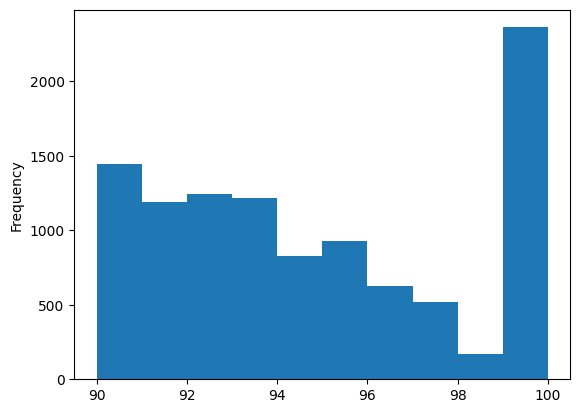

In [59]:
df.loc[df['Ratio Score'] >= 90, 'Ratio Score'].plot(kind='hist')